# Train / Test Split for Pesticide–Respiratory Model

Loads the joint county-level dataset, drops rows missing targets (CASTHMA, COPD), and splits into **train** and **test** sets using a **spatial split** by county and stratifying separately on categorized levels of CASTHMA and COPD.

**Outputs:** `data/train_CASTHMA.csv`, `data/test_CASTHMA.csv`, `data/train_COPD.csv`, and `data/test_COPD.csv`.

**Split:** 80% train, 20% test. Train data will be further split into train and validation data within the cross validation loop in the modeling part (60% train, 20% validation, 20% test). With only 2 years of data (2018–2019), we use a spatial-only split. Split is done separately for the two target variables, CASTHMA and COPD, stratifying on each. Use the validation set for hyperparameter tuning; report final metrics on the hold-out test set.

In [1]:
import os
import numpy as np
import pandas as pd

DATA_DIR = "../data"
JOINT_PATH = os.path.join(DATA_DIR, "joint_county_year_2018_2019.csv")

TRAIN_CASTHMA_PATH = os.path.join(DATA_DIR, "train_CASTHMA.csv")
TEST_CASTHMA_PATH = os.path.join(DATA_DIR, "test_CASTHMA.csv")

TRAIN_COPD_PATH = os.path.join(DATA_DIR, "train_COPD.csv")
TEST_COPD_PATH = os.path.join(DATA_DIR, "test_COPD.csv")

# SPLIT_MAPPING_PATH = os.path.join(DATA_DIR, "split_mapping.csv")

RANDOM_STATE = 42


## Splitting strategy

We use a **spatial split** with **80% train / 20% test**. Choose **SPLIT_LEVEL**:

- **`state`** — Whole states are in one split. Strongest geographic holdout (e.g. “does the model transfer to unseen states?”). Fewer units (~50), so row fractions can deviate a bit from 60/20/20.
- **`county`** — Counties are assigned to train/val/test so row counts are ~60/20/20. More units (~3000), so splits are closer to target and you still evaluate on unseen counties; neighboring counties may be in different splits.

With only **2 years (2018–2019)**, we do not use a temporal hold-out. A spatial-only split avoids overfitting to specific geography.

**Reproducibility:** The split is written to **`data/split_mapping.csv`** (columns: `level`, `geo_id`, `split`). With **USE_SAVED_MAPPING = True**, that file is reused so the same FIPS (or states) stay in train/val/test when you change variables or row filters. To regenerate the split, set **USE_SAVED_MAPPING = False** or delete `split_mapping.csv`.

**Workflow:** Use the **validation set** for hyperparameter tuning and early stopping. Evaluate the chosen model **once** on the hold-out **test set** (e.g. R², RMSE). Do not use the test set for model selection.


## Load and filter

Keep only rows with non-missing targets (CASTHMA, COPD) so we can train and evaluate the model.

In [2]:
df = pd.read_csv(JOINT_PATH)
print("Loaded:", df.shape[0], "rows,", df.shape[1], "columns")

targets = ["CASTHMA", "COPD"]
df_clean = df.dropna(subset=targets)
df_clean = df_clean.reset_index()
print("After dropping rows missing CASTHMA/COPD:", df_clean.shape[0], "rows")
print("Dropped", df.shape[0] - df_clean.shape[0], "rows")

Loaded: 6128 rows, 488 columns
After dropping rows missing CASTHMA/COPD: 6088 rows
Dropped 40 rows


/var/folders/8v/kmqwjstx6sv9d9t9mh2qqpvw0000gn/T/ipykernel_8714/4227805814.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_clean = df_clean.reset_index()


## Normality test for target variables

Check normality for targets (CASTHMA, COPD). If not normal, the best practice is to stratify on the prevalence of targets. Since our targets are continuous, we will need to assign categorical labels to use as the strata (e.g. high, medium, low).

In [ ]:
import seaborn as sns
# first, visualizing the distribution of target variables
sns.histplot(df_clean.CASTHMA)

<Axes: xlabel='COPD', ylabel='Count'>

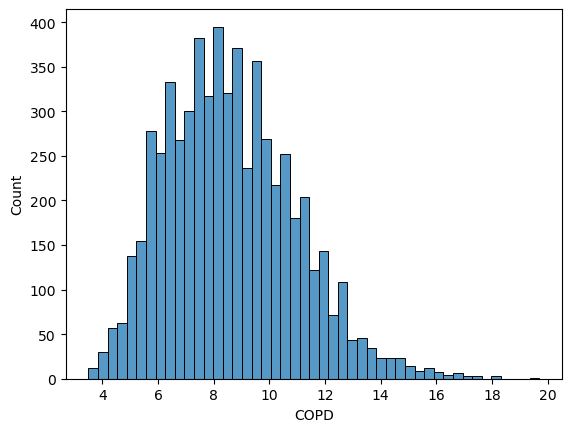

In [ ]:
sns.histplot(df_clean.COPD)

In [ ]:
# run a normality test
from scipy import stats

# Grab data
data = df_clean.CASTHMA

# Perform normality test
stat, p = stats.normaltest(data)
print(f'Statistics={stat:.3f}, p-value={p:.3f}')

# Interpret
alpha = 0.05
if p > alpha:
    print('Sample looks Gaussian (fail to reject H0)')
else:
    print('Sample does not look Gaussian (reject H0)')

Statistics=114.668, p-value=0.000
Sample does not look Gaussian (reject H0)


In [ ]:
# Grab data
data = df_clean.COPD

# Perform normality test
stat, p = stats.normaltest(data)
print(f'Statistics={stat:.3f}, p-value={p:.3f}')

# Interpret
alpha = 0.05
if p > alpha:
    print('Sample looks Gaussian (fail to reject H0)')
else:
    print('Sample does not look Gaussian (reject H0)')

Statistics=279.745, p-value=0.000
Sample does not look Gaussian (reject H0)


Since both of our target variables aren't normal, we should stratify based on it. First, we assign categorical labels by splitting the data into 3 levels (high, medium, low) using 33 and 66 percentile as the cutoff points. Stratifying based on this label will approximate the distribution of the target variables in the train and test sets to the original distribution.

In [ ]:
# either 3 or 5 groups/levels to stratify on.
# 3 groups for now
# CASTHMA
data = df_clean.CASTHMA
n_bins = 3
df_clean['cat3_CASTHMA']=pd.qcut(data, q=n_bins, labels=['low','medium','high'], duplicates='drop')

In [ ]:
# COPD
data = df_clean.COPD
n_bins = 3
df_clean['cat3_COPD']=pd.qcut(data, q=n_bins, labels=['low','medium','high'], duplicates='drop')

In [ ]:
# check if lows are assigned 'low' and highs are assigned 'high' from randomly sampling from the dataframe
df_clean[['CASTHMA','cat3_CASTHMA','COPD','cat3_COPD']].sample(10)

,CASTHMA,cat3_CASTHMA,COPD,cat3_COPD
474,9.3,low,5.8,low
2980,10.5,high,12.4,high
3013,10.1,medium,8.9,medium
3083,10.3,high,10.9,high
4222,10.4,high,9.9,high
1673,8.5,low,6.1,low
5460,9.9,medium,9.2,medium
3576,11.3,high,7.9,medium
2209,9.7,medium,9.1,medium
4823,10.4,high,14.3,high


## Split train and test using StratifiedGroupKFold

Split train and test using:
* 5 splits - this leads to 80% train and 20% test data
* county (FIPS) as groups - this assigns all datapoints from the same county to be in either train or test but not be split between the two.
* CASTHMA/COPD levels as strata - this keeps the distribution of target variables similar across train and test sets

Splits are done separtely for CASTHMA and COPD and thus will be saved in two pairs of train and test sets.
Even though we're using a 'KFold' method, we only need one iteration of the train/test split. We will use the same split method within our cross-validation loop in the actual modeling step to train and validate iteratively.

In [ ]:
from sklearn.model_selection import StratifiedGroupKFold
# first, splitting between training+validation (80%) and test (20%)
sgkf = StratifiedGroupKFold(n_splits=5,random_state = RANDOM_STATE, shuffle=True) # shuffle so that we randomly assign counties to test
y=df_clean.cat3_CASTHMA # the class we want to stratify on - in this case the categorical labels for CASTHMA
X=df_clean[['FIPS','CASTHMA']] # don't need full data for this one
groups=df_clean.FIPS # using county index as groups

# we're looping but will grab only the first fold and save out the test data
for i, (train_index, test_index) in enumerate(sgkf.split(X, y, groups)):
    if i == 0:
        break
df_test = df_clean.iloc[test_index,:]
df_train = df_clean.iloc[train_index,:]

In [ ]:
# double checking if the ratios are the same between train and test
df_test.value_counts(subset='cat3_CASTHMA',normalize=True)

cat3_CASTHMA
medium    0.353328
low       0.334429
high      0.312243
Name: proportion, dtype: float64

In [ ]:
df_train.value_counts(subset='cat3_CASTHMA',normalize=True)

cat3_CASTHMA
medium    0.352494
low       0.334634
high      0.312872
Name: proportion, dtype: float64

In [ ]:
# checking if any county was split between train/valid and test
np.intersect1d(np.unique(df_test.FIPS),np.unique(df_train.FIPS))

array([], dtype=int64)

In [ ]:
train_CASTHMA, test_CASTHMA = df_train, df_test

In [ ]:
# repeat for COPD
y=df_clean.cat3_COPD
X=df_clean[['FIPS','COPD']]
groups=df_clean.FIPS

# grab only the first fold and save out the test data
for i, (train_index, test_index) in enumerate(sgkf.split(X, y, groups)):
    if i == 0:
        break
df_test = df_clean.iloc[test_index,:]
df_train = df_clean.iloc[train_index,:]

# train_COPD, test_COPD = df_train, df_test

In [ ]:
# double checking if the ratios are the same between train/valid and test
print(df_test.value_counts(subset='cat3_COPD',normalize=True))
print(df_train.value_counts(subset='cat3_COPD',normalize=True))

cat3_COPD
low       0.344289
medium    0.328677
high      0.327034
Name: proportion, dtype: float64
cat3_COPD
low       0.344488
medium    0.329091
high      0.326422
Name: proportion, dtype: float64


In [ ]:
# checking if any county was split between train/valid and test
np.intersect1d(np.unique(df_test.FIPS),np.unique(df_train.FIPS))

array([], dtype=int64)

In [ ]:
train_COPD, test_COPD = df_train, df_test

## Save

**Next steps:** Split **train** and **validation** within cross-validation loop. Use the **validation set** for hyperparameter tuning and early stopping. After selecting the best model, evaluate it **once** on the hold-out **test set** (e.g. R², RMSE). Do not use the test set for any model selection.

In [ ]:
TRAIN_CASTHMA_PATH = os.path.join(DATA_DIR, "train_CASTHMA.csv")
TEST_CASTHMA_PATH = os.path.join(DATA_DIR, "test_CASTHMA.csv")

TRAIN_COPD_PATH = os.path.join(DATA_DIR, "train_COPD.csv")
TEST_COPD_PATH

train_CASTHMA.to_csv(TRAIN_CASTHMA_PATH, index=False)
test_CASTHMA.to_csv(TEST_CASTHMA_PATH, index=False)

train_COPD.to_csv(TRAIN_COPD_PATH, index=False)
test_COPD.to_csv(TEST_COPD_PATH, index=False)

print("Saved:", TRAIN_CASTHMA_PATH, "|", TEST_CASTHMA_PATH, "|", TRAIN_COPD_PATH, "|", TEST_COPD_PATH)

Saved: ../data/train_CASTHMA.csv | ../data/test_CASTHMA.csv | ../data/train_COPD.csv | ../data/test_COPD.csv
